In [1]:
from pathlib import Path
from itertools import groupby
import h5py
import numpy as np
import numpy.typing as npt
from numpy.lib.stride_tricks import sliding_window_view
import matplotlib.pyplot as plt
from src.module.utils import load_config
from src.module.labelling import Hypophet, HypophetVersion2

In [2]:
def set_environment(config):
    src_path = Path(config["data_path"]).expanduser() / "02_04.processed"
    save_path = Path(config["data_path"]).expanduser() / "02_04.processed"
    file_path = sorted(src_path.rglob(f"*{config['fs']}fs*processed.h5"))
    env = {"src_path": src_path, "save_path": save_path, "file_path": file_path}
    return env


def load_h5(file_path) -> tuple:
    with h5py.File(file_path, "r") as f:
        ts = f["signal/ts"][:]
        sig = f["signal/abp"][:]
        mbp = f["signal/mbp"][:]
        sqi = f["signal/sqi"][:]
        fs = f["signal"].attrs["fs"]
        sig_len = f["signal"].attrs["len"]
        cid = f.attrs["caseid"]

    return cid, fs, sig_len, ts, sig, mbp, sqi

In [3]:
config = load_config("../../config/conf.yaml")
env = set_environment(config)

In [4]:
print("Hypophetversion2 strategy selected")
strategy = HypophetVersion2()

Hypophetversion2 strategy selected


In [5]:
input_len = config["input_len"]
pred_len = config["pred_len"]
grp = config["event_condition"]["pos"]["group_range"]
adj = config["event_condition"]["neg"]["adjacency"]

In [52]:
file_path = env["file_path"][-15]
print(file_path)

/Users/chishinhwang/Github/SNU-Hypo10Pred_v2/data/02_04.processed/6363/6363_100fs_processed.h5


In [53]:
cid, _, _, _, sig, mbp, sqi = load_h5(file_path)
case_path = Path(config["data_path"]).expanduser() / "02_04.processed" / cid
fname = file_path.name.split(".")[0]
pos_name = (
    f"{fname}_in{input_len}out{pred_len}_grp{grp}_hypophetversion2_pos_events.npy"
)
neg_name = (
    f"{fname}_in{input_len}out{pred_len}_adj{adj}_hypophetversion2_neg_events.npy"
)

In [54]:
is_bad_quality = sqi > config["sqi"]["threshold"]
masked_mbp = np.where(is_bad_quality, 0, mbp)

### HypophetVersion2 implementation

In [40]:
def set_window_of(arr, win_size) -> tuple[npt.NDArray, npt.NDArray]:
    """
    Windowing input array with half-overlapping windows.
    """
    if len(arr) < win_size:
        return np.array([], dtype=np.float32), np.array([], dtype=np.float32)
    windows = sliding_window_view(arr, win_size)[:: win_size // 2]
    windows_idx = sliding_window_view(np.arange(arr.size), win_size)[:: win_size // 2]
    # end point 에 1을 더하여 이후 배열을 생성할 때 용이하도록 한다.
    windows_range = np.hstack([windows_idx[:, 0:1], windows_idx[:, -1:] + 1])
    return windows, windows_range


def group_event(events, config, grp_rng) -> npt.NDArray:
    """
    * Make range for grouping for each event.
    * Events intersects with each others get a group number.
    *
    * For example, if segment A's range is (1200, 2500) and segment B's range is (2400, 3000),
    * each segment is intersect at (2400, 2500).
    * Thus they can be merged into new segment with range (1200, 3000).
    """
    # event_cond = config["event_condition"]["pos"]
    # grp_rng = event_cond["group_range"]

    grp_len = config["fs"] * 60 * grp_rng
    events_with_grp_rng = [
        (event[0] - grp_len, event[-1] + grp_len) for event in events
    ]

    group_no = np.zeros(len(events_with_grp_rng))
    for i in range(len(events_with_grp_rng) - 1):
        segment = events_with_grp_rng[i]
        next_segment = events_with_grp_rng[i + 1]
        start, end = segment[0], segment[-1]

        if start <= next_segment[0] < end:
            group_no[i + 1] = group_no[i]
        else:
            group_no[i + 1] = group_no[i] + 1

    events_with_grp = tuple(zip(events, group_no))
    grp_events = []
    for _, grp in groupby(events_with_grp, lambda x: x[1]):
        temp_grp = list(grp)
        start_idx, end_idx = temp_grp[0][0][0], temp_grp[-1][0][-1]
        grp_events.append((start_idx, end_idx))
    return np.vstack(grp_events, dtype=np.int32)

In [41]:
# mark_pos_event
# slide 1-minute half-overlapping window defining hypotension event
# window: t ≤ x < t + 6000

fs = config["fs"]
win_size = config["event_condition"]["pos"]["N"] * fs

try:
    windows, win_rng = set_window_of(masked_mbp, win_size)
    is_window_valid = np.all(windows != 0, axis=1)
    is_positive = windows.mean(axis=1) < 65
    pos_event = win_rng[is_window_valid & is_positive]
    pos_event = group_event(pos_event, config, grp_rng=0)

    pos_event = np.where(pos_event < 0, 0, pos_event)
except Exception as e:
    print(f"Error occurred while processing positive events: {e}")
    pos_event = np.array([], dtype=np.int32)

actual_pos_event = pos_event.copy()

In [42]:
# mark_gray_zone
# gray zone은 actual pos event의 양끝에서 N분으로 정의된다.
# 만약 gray zone이 다른 actual pos event와 겹친다면, actual pos event 전까지만 gray zone으로 정의한다.

adj = fs * 60 * config["adjacency"]
soft_gray_zone, hard_gray_zone = [], []
for e in actual_pos_event:
    left_end, right_start = e[0], e[1]
    left_start, right_end = left_end - adj, right_start + adj
    soft_gray_zone.append((left_start, left_end))
    hard_gray_zone.append((right_start, right_end))

try:
    soft_gray_zone = np.vstack(soft_gray_zone)
    soft_gray_zone = np.where(soft_gray_zone < 0, 0, soft_gray_zone)
except ValueError:
    print("No soft gray zones defined.")
    soft_gray_zone = np.array([], dtype=np.int32)

try:
    hard_gray_zone = np.vstack(hard_gray_zone)
    hard_gray_zone = np.where(
        hard_gray_zone >= len(masked_mbp), len(masked_mbp), hard_gray_zone
    )
except ValueError:
    print("No hard gray zones defined.")
    hard_gray_zone = np.array([], dtype=np.int32)

In [43]:
# label_predicted_pos_event
# actual pos event의 시작부분으로부터 N분 lookback으로 정의된다.
# 15분 lookback으로부터 30초 non-overlapping window를 추출한다고 하면,
# 마지막 새그먼트 즉, actual과 겹치는 인덱스를 가지는 새그먼트는 배제되어야 한다.
# predicted window: t ≤ x < t + pred_len

pred_len = config["pred_len"] * fs
predicted_pos_event = []
for e in actual_pos_event:
    pred_end = e[0]
    pred_start = pred_end - pred_len
    predicted_pos_event.append((pred_start, pred_end))

try:
    predicted_pos_event = np.vstack(predicted_pos_event)
    predicted_pos_event = np.where(predicted_pos_event < 0, 0, predicted_pos_event)
except ValueError:
    print("No predicted positive events defined.")
    predicted_pos_event = np.array([], dtype=np.int32)

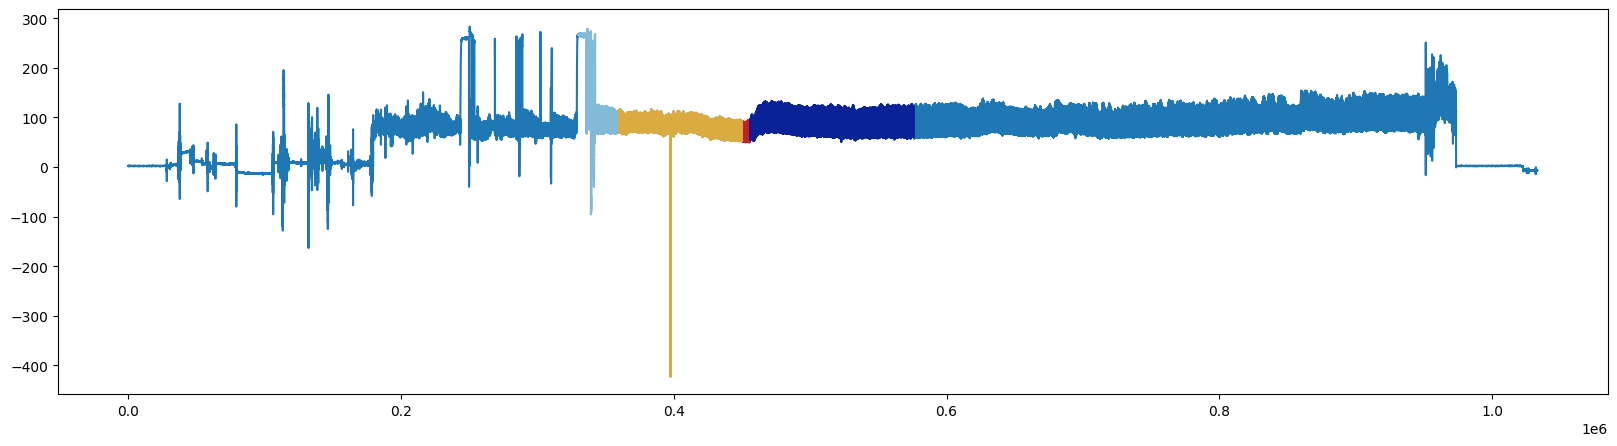

In [44]:
plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in actual_pos_event:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)
for e in soft_gray_zone:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)
for e in hard_gray_zone:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)
for e in predicted_pos_event:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)
plt.show()

In [45]:
# 각 라벨의 index를 먼저 구한다.
# 그것을 정해진 순서에 따라 signal에 레이어를 쌓듯 쌓아올린다.
# non-hypotension -> soft gray zone -> predicted -> hard gray zone -> actual
# actual pos(2), predicted pos(1), neg(0), soft gray zone(-1), hard gray zone(-2)

label_map = np.zeros_like(masked_mbp)

for e in soft_gray_zone:
    label_map[range(*e)] = -1

for e in predicted_pos_event:
    label_map[range(*e)] = 1

for e in hard_gray_zone:
    label_map[range(*e)] = -2

for e in actual_pos_event:
    label_map[range(*e)] = 2

In [46]:
# label_map으로부터 각 event를 slice하여 추출한다.
# neg_events는 모든 새그먼트의 길이가 일정하지 않다.
# actual_pos_events는 중첩되는 이벤트들이 결합되므로 길이가 일정하지 않다.
# predicted_pos_events는 soft_gray_zone으로 인해 보장된 15분 길이를 확보할 수 있으므로 모두 15분으로 일정하다.
# soft_gray_zones는 hard_gray_zone과 겹치는 부분이 존재할 수 있으므로 길이가 일정하지 않다.
# hard_gray_zones는 actual_pos_events와 겹치는 부분이 존재할 수 있으므로 길이가 일정하지 않다.

neg_events = np.split(
    np.where(label_map == 0)[0],
    np.where(np.diff(np.where(label_map == 0)[0]) != 1)[0] + 1,
)

actual_pos_events = np.split(
    np.where(label_map == 2)[0],
    np.where(np.diff(np.where(label_map == 2)[0]) != 1)[0] + 1,
)

predicted_pos_events = np.split(
    np.where(label_map == 1)[0],
    np.where(np.diff(np.where(label_map == 1)[0]) != 1)[0] + 1,
)

soft_gray_zones = np.split(
    np.where(label_map == -1)[0],
    np.where(np.diff(np.where(label_map == -1)[0]) != 1)[0] + 1,
)

hard_gray_zones = np.split(
    np.where(label_map == -2)[0],
    np.where(np.diff(np.where(label_map == -2)[0]) != 1)[0] + 1,
)

In [47]:
try:
    neg_events = np.vstack([(e[0], e[-1] + 1) for e in neg_events])
except ValueError and IndexError:
    print("No negative events defined.")
    neg_events = np.array([], dtype=np.int32)

try:
    actual_pos_events = np.vstack([(e[0], e[-1] + 1) for e in actual_pos_events])
except ValueError and IndexError:
    print("No positive events defined.")
    actual_pos_events = np.array([], dtype=np.int32)

try:
    predicted_pos_events = np.vstack([(e[0], e[-1] + 1) for e in predicted_pos_events])
except ValueError and IndexError:
    print("No predicted positive events defined.")
    predicted_pos_events = np.array([], dtype=np.int32)

try:
    soft_gray_zones = np.vstack([(e[0], e[-1] + 1) for e in soft_gray_zones])
except ValueError and IndexError:
    print("No soft gray zones defined.")
    soft_gray_zones = np.array([], dtype=np.int32)

try:
    hard_gray_zones = np.vstack([(e[0], e[-1] + 1) for e in hard_gray_zones])
except ValueError and IndexError:
    print("No hard gray zones defined.")
    hard_gray_zones = np.array([], dtype=np.int32)

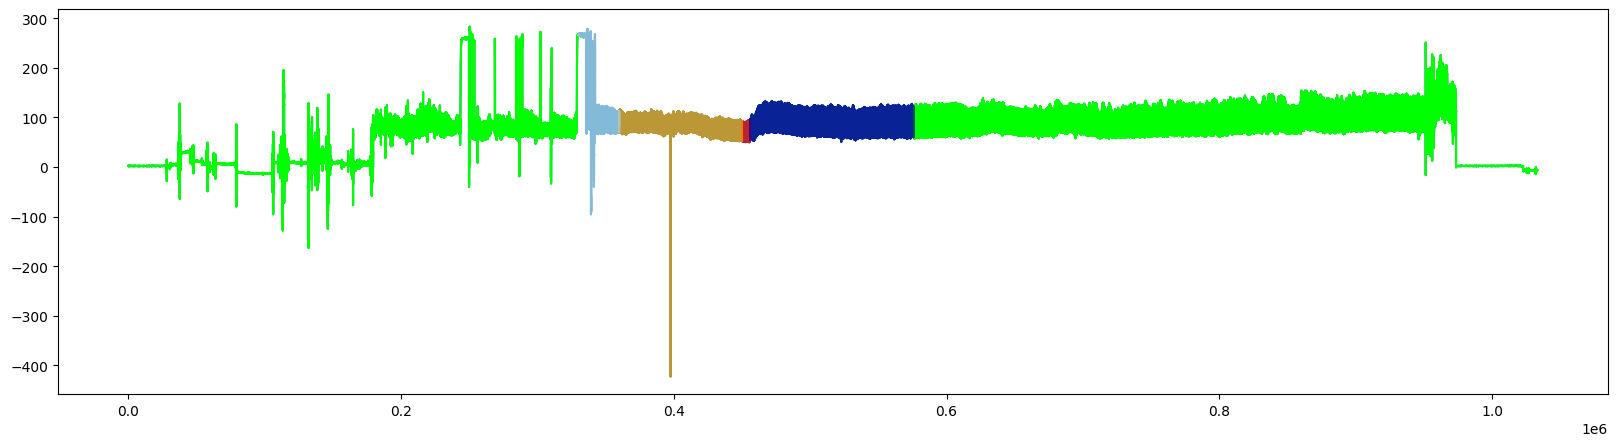

In [48]:
# 겹쳐보이는 지점들은 실제로는 겹치지 않는다. 해상도 문제로 인한 것이다.

plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in neg_events:
    plt.plot(range(*e), sig[range(*e)], color="lime")

for e in actual_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)

for e in predicted_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)

for e in soft_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)

for e in hard_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)
plt.show()

### HypophetVersion2

In [49]:
neg_events, actual_pos_events, pred_pos_events, soft_gray_zones, hard_gray_zones = (
    strategy.label_event(masked_mbp, config)
)

In [50]:
neg_events = np.load(
    case_path / "5487_100fs_processed_hypophetversion2_adj20_neg_events.npy"
)
actual_pos_events = np.load(
    case_path / "5487_100fs_processed_hypophetversion2_adj20_actual_pos_events.npy"
)
pred_pos_events = np.load(
    case_path / "5487_100fs_processed_hypophetversion2_adj20_pred_pos_events.npy"
)
soft_gray_zones = np.load(
    case_path / "5487_100fs_processed_hypophetversion2_adj20_soft_gray_zones.npy"
)
hard_gray_zones = np.load(
    case_path / "5487_100fs_processed_hypophetversion2_adj20_hard_gray_zones.npy"
)

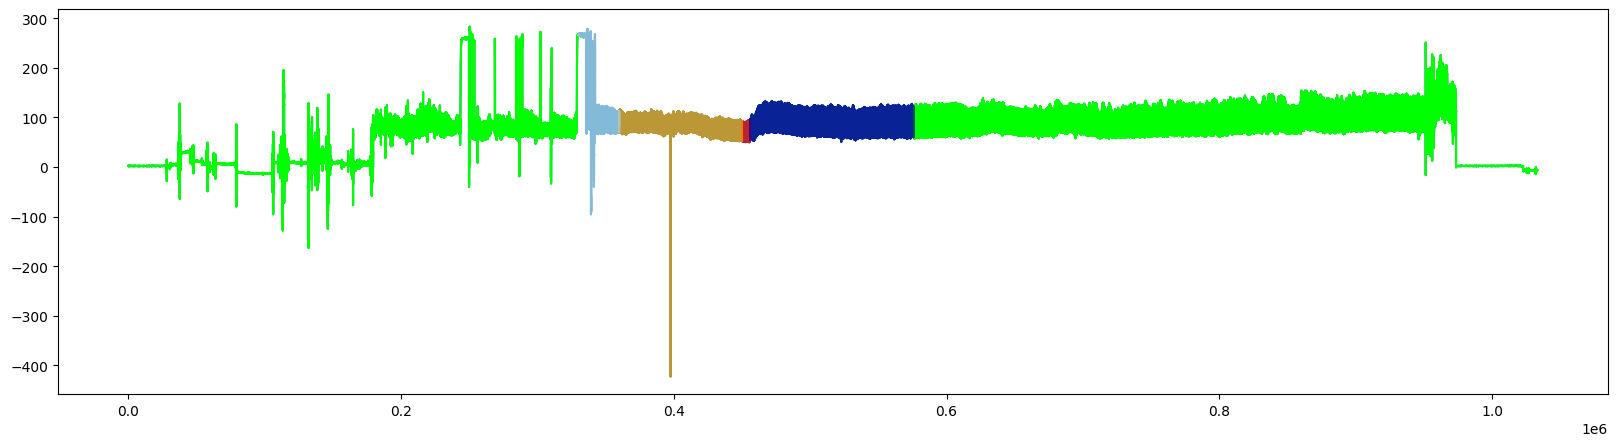

In [51]:
# 겹쳐보이는 지점들은 실제로는 겹치지 않는다. 해상도 문제로 인한 것이다.

plt.figure(figsize=(20, 5))
plt.plot(sig)

for e in neg_events:
    plt.plot(range(*e), sig[range(*e)], color="lime")

for e in actual_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="red", alpha=0.7)

for e in pred_pos_events:
    plt.plot(range(*e), sig[range(*e)], color="orange", alpha=0.7)

for e in soft_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="lightblue", alpha=0.7)

for e in hard_gray_zones:
    plt.plot(range(*e), sig[range(*e)], color="darkblue", alpha=0.7)
plt.show()

In [82]:
print(
    np.load(case_path / "0053_100fs_processed_in30out900_grp5_hypophet_pos_events.npy"),
    np.load(
        case_path / "0053_100fs_processed_in30out900_adj20_hypophet_neg_events.npy"
    ),
)

[] [[      0 1353475]]
